核心假设：实例时由多个参数未知的高斯分布混合生成的

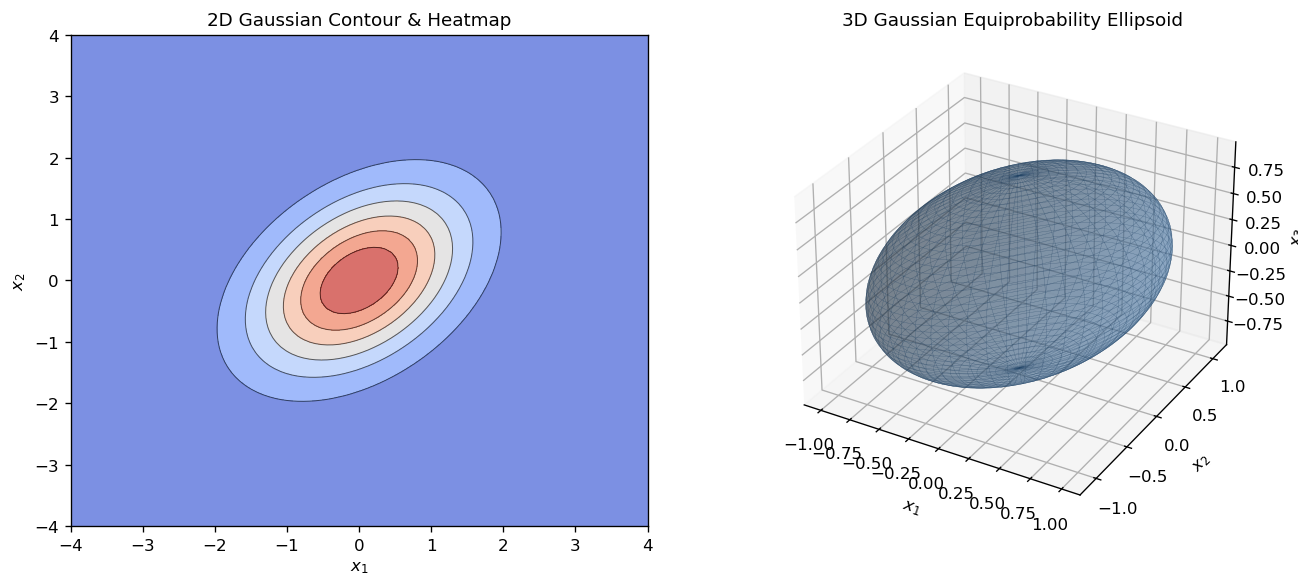

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from mpl_toolkits.mplot3d import Axes3D

color_1d = "#36648B"
cmap_2d = "coolwarm"
color_ellipsoid = "#4477AA"

fig = plt.figure(figsize=(16, 5), dpi=120)

# ====================== 子图1：一维高斯分布 ======================
# ax1 = fig.add_subplot(1, 3, 1)
# mu1, sigma1 = 0, 1
# x1 = np.linspace(-4, 4, 200)
# y1 = norm.pdf(x1, loc=mu1, scale=sigma1)

# ax1.plot(x1, y1, c=color_1d, lw=2.2)
# ax1.fill_between(x1, y1, alpha=0.3, color=color_1d)
# ax1.set_title("1D Gaussian", fontsize=11)
# ax1.grid(alpha=0.3)
# ax1.set_xlabel("x")
# ax1.set_ylabel("Probability Density")

# ====================== 子图2：二维高斯分布（热力+等高线） ======================
ax2 = fig.add_subplot(1, 3, 2)
mu2 = np.array([0, 0])
cov2 = np.array([[1, 0.4],
                 [0.4, 1]])

xx, yy = np.meshgrid(np.linspace(-4, 4, 100),
                     np.linspace(-4, 4, 100))
pos = np.dstack((xx, yy))
rv2 = multivariate_normal(mu2, cov2)
z2 = rv2.pdf(pos)

contour = ax2.contourf(xx, yy, z2, cmap=cmap_2d, alpha=0.75)
ax2.contour(xx, yy, z2, colors="black", linewidths=0.6, alpha=0.6)
ax2.set_title("2D Gaussian Contour & Heatmap", fontsize=11)
ax2.set_xlabel("$x_1$")
ax2.set_ylabel("$x_2$")

# ====================== 子图3：三维高斯 1σ椭球等值面 ======================
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
mu3 = np.array([0, 0, 0])
cov3 = np.array([[1, 0.3, 0.2],
                 [0.3, 1.2, 0.1],
                 [0.2, 0.1, 0.9]])

# 构造椭球：(x-μ)^T Σ⁻¹ (x-μ) = 1
n = 100
theta = np.linspace(0, 2*np.pi, n)
phi = np.linspace(0, np.pi, n)
theta, phi = np.meshgrid(theta, phi)

# 单位球面
x_sph = np.cos(theta)*np.sin(phi)
y_sph = np.sin(theta)*np.sin(phi)
z_sph = np.cos(phi)

# Cholesky分解，球面变换为高斯椭球
L = np.linalg.cholesky(cov3)
xyz = L @ np.vstack([x_sph.ravel(), y_sph.ravel(), z_sph.ravel()])
x_ell = xyz[0, :].reshape(x_sph.shape) + mu3[0]
y_ell = xyz[1, :].reshape(y_sph.shape) + mu3[1]
z_ell = xyz[2, :].reshape(z_sph.shape) + mu3[2]

ax3.plot_surface(x_ell, y_ell, z_ell, color=color_ellipsoid, alpha=0.35, edgecolor="#224466", lw=0.2)
ax3.set_title("3D Gaussian Equiprobability Ellipsoid", fontsize=11)
ax3.set_xlabel("$x_1$")
ax3.set_ylabel("$x_2$")
ax3.set_zlabel("$x_3$")
ax3.grid(alpha=0.25)

plt.tight_layout()
plt.show()

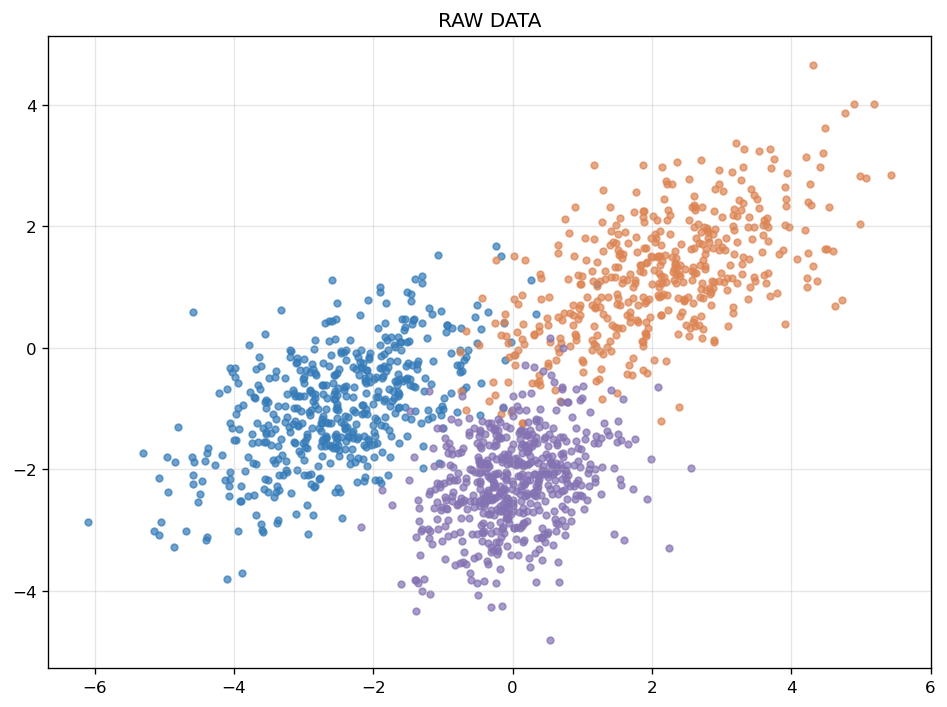

In [6]:
from sklearn.mixture import GaussianMixture

np.random.seed(42)

n1, n2, n3 = 500, 450, 550

# 簇1
mu1 = np.array([-2.5, -1.0])
cov1 = np.array([[1.2, 0.6],
                 [0.6, 0.9]])

# 簇2
mu2 = np.array([2.2, 1.2])
cov2 = np.array([[1.6, 0.9],
                 [0.9, 1.1]])

# 簇3
mu3 = np.array([0, -2.2])
cov3 = np.array([[0.5, 0.15],
                 [0.15, 0.6]])


data1 = np.random.multivariate_normal(mu1, cov1, n1)
data2 = np.random.multivariate_normal(mu2, cov2, n2)
data3 = np.random.multivariate_normal(mu3, cov3, n3)

X = np.vstack([data1, data2, data3])
y_true = np.hstack([np.zeros(n1), np.ones(n2), np.full(n3, 2)])


plt.figure(figsize=(8, 6), dpi=120)
palette = ["#347bb8", "#dd8452", "#8472b2"]
for c in range(3):
    mask = y_true == c
    plt.scatter(X[mask, 0], X[mask, 1], c=palette[c], s=16, alpha=0.7)

plt.title("RAW DATA")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
gm = GaussianMixture(n_components=3, n_init=10)
gm.fit(X)
y_predict = gm.predict(X)

means = gm.means_          # 高斯中心点
covs = gm.covariances_     # 协方差矩阵
weights = gm.weights_

print(gm.weights_)
print(gm.means_)
print(gm.covariances_)
print(gm.converged_)
print(gm.n_iter_)

[0.3761377  0.29386565 0.32999665]
[[ 0.01549362 -2.17415911]
 [ 2.11892241  1.21257376]
 [-2.53235418 -0.99426399]]
[[[0.51322229 0.15793719]
  [0.15793719 0.63134038]]

 [[1.47308311 0.69579941]
  [0.69579941 0.93735196]]

 [[1.09088883 0.5402244 ]
  [0.5402244  0.87139934]]]
True
6


d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklea

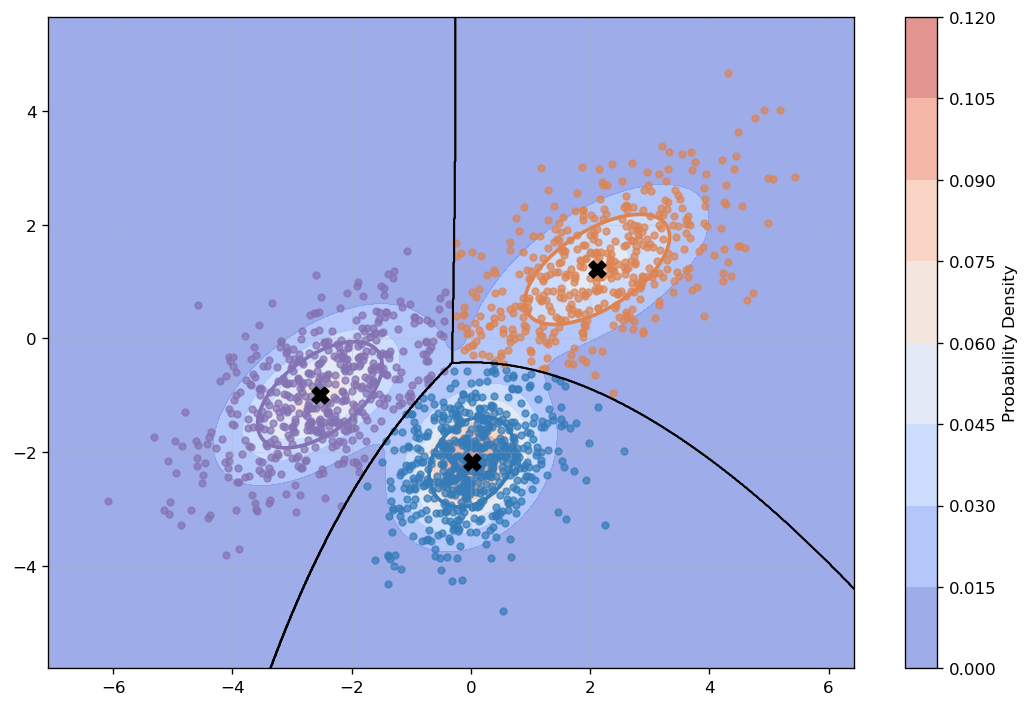

In [17]:
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()
    vals, vecs = np.linalg.eigh(covariance)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * np.sqrt(vals)
    ellip = Ellipse(xy=position, width=width, height=height, angle=theta,** kwargs)
    ax.add_artist(ellip)
    return ellip

plt.figure(figsize=(9, 6), dpi=120)
ax = plt.gca()

# 绘图网格
h = 0.01
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

# score_samples 返回 log 概率密度，转成真实概率密度
log_density = gm.score_samples(grid)
density = np.exp(log_density)
density = density.reshape(xx.shape)

# 绘制密度热力底色 + 色条
contour_fill = ax.contourf(xx, yy, density, cmap="coolwarm", alpha=0.55)
plt.colorbar(contour_fill, ax=ax, label="Probability Density")

# 绘制决策边界
grid_label = gm.predict(grid)
grid_label = grid_label.reshape(xx.shape)
# 黑色实线：类别切换的决策分界线
ax.contour(xx, yy, grid_label, colors="black", linewidths=1, alpha=0.7)

palette = ["#347bb8", "#dd8452", "#8472b2"]
for c_idx in range(3):
    mask = y_predict == c_idx
    ax.scatter(X[mask, 0], X[mask, 1], c=palette[c_idx], s=16, alpha=0.7)

# 高斯轮廓 + 中心点
for i in range(3):
    draw_ellipse(means[i], covs[i], edgecolor=palette[i], facecolor="none", lw=2.2)
    ax.scatter(means[i,0], means[i,1], marker="X", c="black", s=100, zorder=10)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**如何确定集群数：最小化理论信息量准则**

1. 贝叶斯信息准则 $\text{BIC} = \log(m)p - 2\log(\hat{\mathcal{L}})$
2. 赤池信息准则 $\text{AIC} = 2p - 2\log(\hat{\mathcal{L}})$

核心思想：对具有更多要学习的参数的模型进行惩罚，奖励非常拟合数据的模型

d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklea

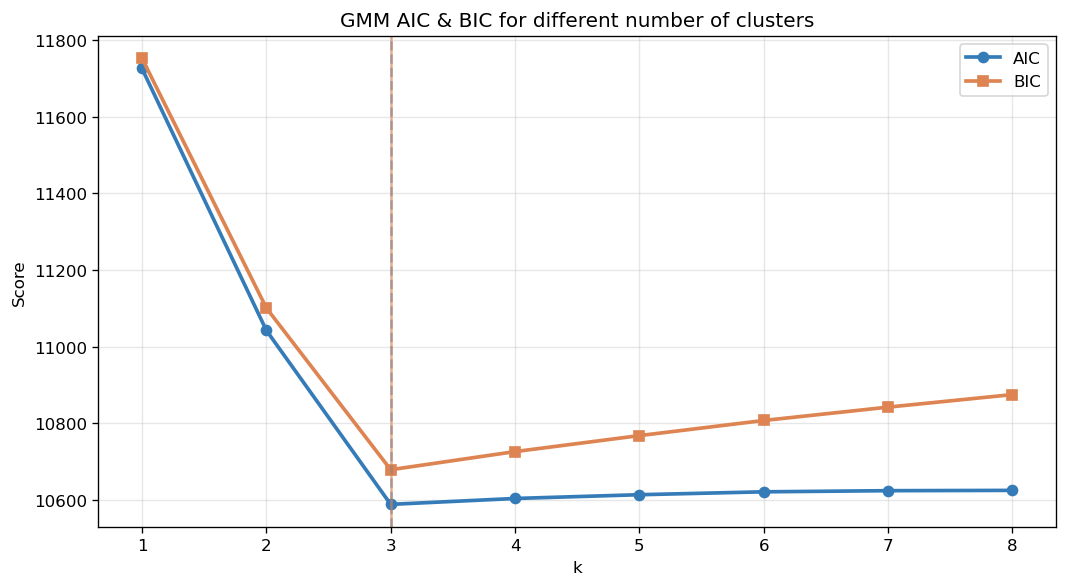

In [ ]:
k_range = np.arange(1, 9)
aic_scores = []
bic_scores = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, n_init=10, random_state=42)
    gmm.fit(X)
    aic_scores.append(gmm.aic(X))
    bic_scores.append(gmm.bic(X))

plt.figure(figsize=(9, 5), dpi=120)
plt.plot(k_range, aic_scores, marker="o", c="#347bb8", label="AIC", lw=2.2)
plt.plot(k_range, bic_scores, marker="s", c="#dd8452", label="BIC", lw=2.2)

# 标记最小值位置
best_k_aic = k_range[np.argmin(aic_scores)]
best_k_bic = k_range[np.argmin(bic_scores)]
plt.axvline(x=best_k_aic, color="#347bb8", linestyle="--", alpha=0.6)
plt.axvline(x=best_k_bic, color="#dd8452", linestyle="--", alpha=0.6)

plt.xlabel("k")
plt.ylabel("Score")
plt.title("GMM AIC & BIC for different number of clusters")
plt.xticks(k_range)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()